 # Notebook 01 — Exploratory Data Analysis

 **Project:** Credit Card Fraud Detection

 **Stage:** EDA — What is in the data before any transformation?



 ---

 ## 0. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # project root

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.data_ingestion  import DataIngestion
from src.data.data_validation import DataValidator
from src.visualization.eda_plots import EDAVisualizer
from src.visualization.eda_plots import EDAVisualizer

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

SAVE_DIR = "../reports/figures"
viz = EDAVisualizer(save_dir=SAVE_DIR)


 ---

 ## 1. Dataset Overview

 ### 1.1 What is this dataset about?



 | | |

 |---|---|

 | **Domain** | Financial fraud detection |

 | **Source** | Kaggle — ULB Credit Card Fraud |

 | **Task** | Binary classification: `Class=0` (legit) vs `Class=1` (fraud) |

 | **Problem type** | Anomaly detection / imbalanced binary classification |

 | **Rows** | 284,807 European credit card transactions (2 days, Sep 2013) |

 | **Features** | V1–V28 (PCA-transformed), `Time`, `Amount`, `Class` |

 | **Challenge** | Extreme class imbalance — only 0.173% are fraudulent |

In [2]:
# ── Load data ────────────────────────────────────────────────────
ingestor = DataIngestion(config_path="../configs/data_config.yaml")
df = ingestor.load(path="../data/raw/creditcard.csv")


2026-06-13 03:29:23 | INFO     | src.data.data_ingestion | Loading data from: E:\Python projects\fraud-detection-system\data\raw\creditcard.csv
2026-06-13 03:29:25 | INFO     | src.data.data_ingestion | Loaded  shape  : (284807, 31)
2026-06-13 03:29:25 | INFO     | src.data.data_ingestion | Memory usage   : 70.63 MB
2026-06-13 03:29:25 | INFO     | src.data.data_ingestion | Target 'Class' — fraud rate: 0.1727%


In [3]:
# ── Basic info ───────────────────────────────────────────────────
print("=== df.shape ===")
print(df.shape)

print("\n=== df.dtypes ===")
print(df.dtypes)

print("\n=== df.info() ===")
df.info()


=== df.shape ===
(284807, 31)

=== df.dtypes ===
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 n

In [4]:
print("=== df.describe() ===")
df.describe().T.style.background_gradient(cmap="Blues", subset=["mean", "std"])


=== df.describe() ===


,count,mean,std,min,25%,50%,75%,max
Time,284807.000000,94813.859575,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.000000,0.000000,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.000000,0.000000,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.000000,-0.000000,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.000000,0.000000,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.000000,0.000000,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.000000,0.000000,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.000000,-0.000000,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.000000,0.000000,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.000000,-0.000000,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [6]:
print("=== df.isnull().sum() ===")
print(df.isnull().sum())
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")


=== df.isnull().sum() ===
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total missing cells: 0


In [7]:
print("=== Unique values per column ===")
for col in df.columns:
    print(f"  {col:<20} : {df[col].nunique():>8,} unique")


=== Unique values per column ===
  Time                 :  124,592 unique
  V1                   :  275,663 unique
  V2                   :  275,663 unique
  V3                   :  275,663 unique
  V4                   :  275,663 unique
  V5                   :  275,663 unique
  V6                   :  275,663 unique
  V7                   :  275,663 unique
  V8                   :  275,663 unique
  V9                   :  275,663 unique
  V10                  :  275,663 unique
  V11                  :  275,663 unique
  V12                  :  275,663 unique
  V13                  :  275,663 unique
  V14                  :  275,663 unique
  V15                  :  275,663 unique
  V16                  :  275,663 unique
  V17                  :  275,663 unique
  V18                  :  275,663 unique
  V19                  :  275,663 unique
  V20                  :  275,663 unique
  V21                  :  275,663 unique
  V22                  :  275,663 unique
  V23                  :

In [8]:
print("=== Duplicated rows ===")
n_dup = df.duplicated().sum()
print(f"  {n_dup:,} duplicates ({n_dup/len(df):.3%})")


=== Duplicated rows ===
  1,081 duplicates (0.380%)


 ### 1.2 Dataset overview table

  Saved → ..\reports\figures\01_overview_table.png


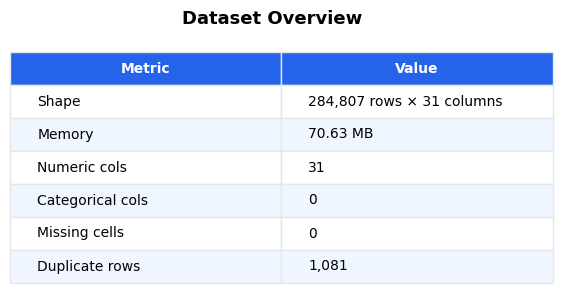

In [9]:
fig = viz.plot_overview_table(df)
plt.show()


 ### 1.3 Target variable — Class distribution

In [10]:
print("=== Class distribution ===")
vc = df["Class"].value_counts()
print(vc.to_string())
print(f"\nFraud rate     : {df['Class'].mean():.4%}")
print(f"Imbalance ratio: {vc[0]/vc[1]:.0f}:1")


=== Class distribution ===
Class
0    284315
1       492

Fraud rate     : 0.1727%
Imbalance ratio: 578:1


  Saved → ..\reports\figures\03_class_distribution.png


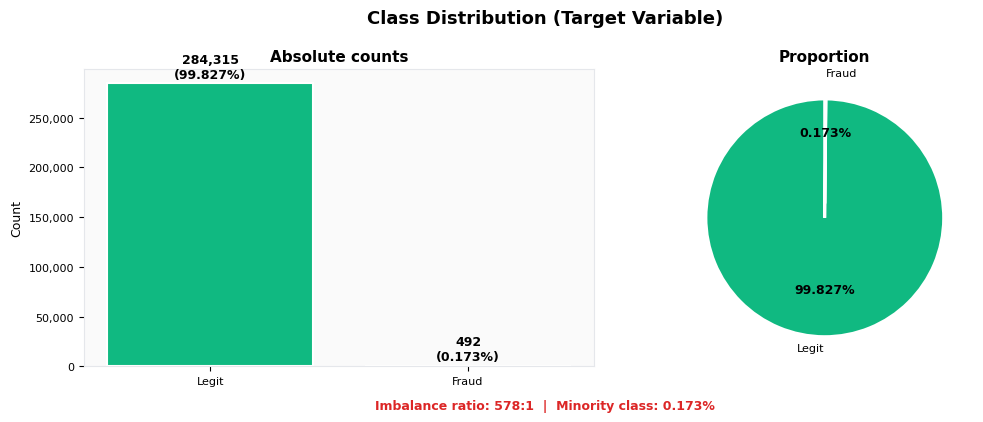

In [11]:
fig = viz.plot_class_distribution(df["Class"])
plt.show()


 ---

 ## 2. Missing Values

  Saved → ..\reports\figures\02_missing_heatmap.png


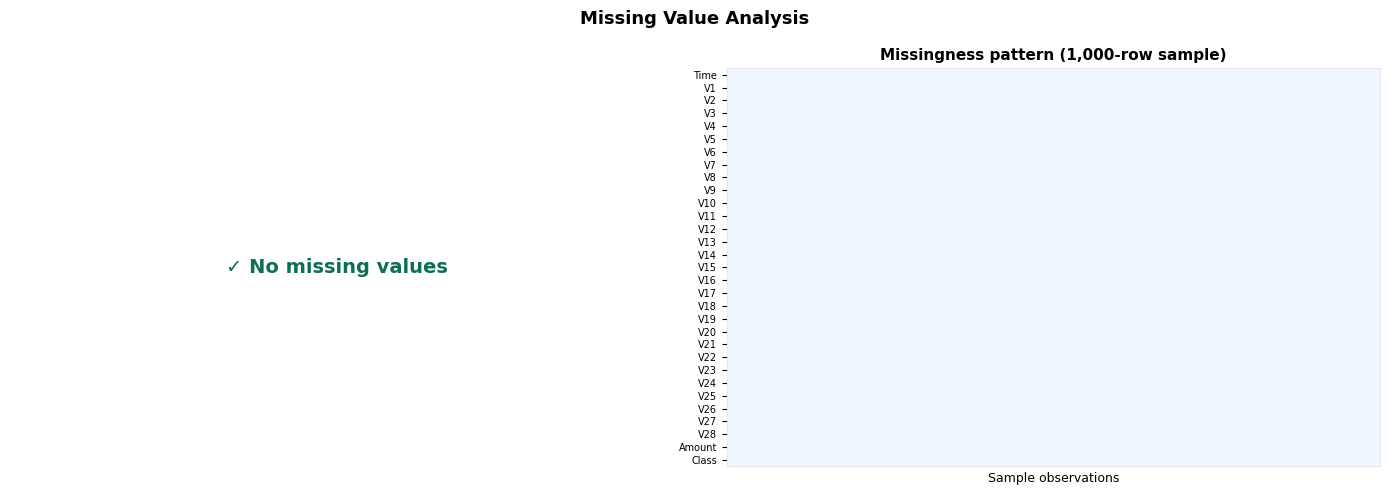

In [12]:
fig = viz.plot_missing_heatmap(df)
plt.show()


 ---

 ## 3. Feature Distributions

  Saved → ..\reports\figures\04_feature_histograms.png
  Saved → ..\reports\figures\04_feature_histograms_by_class.png


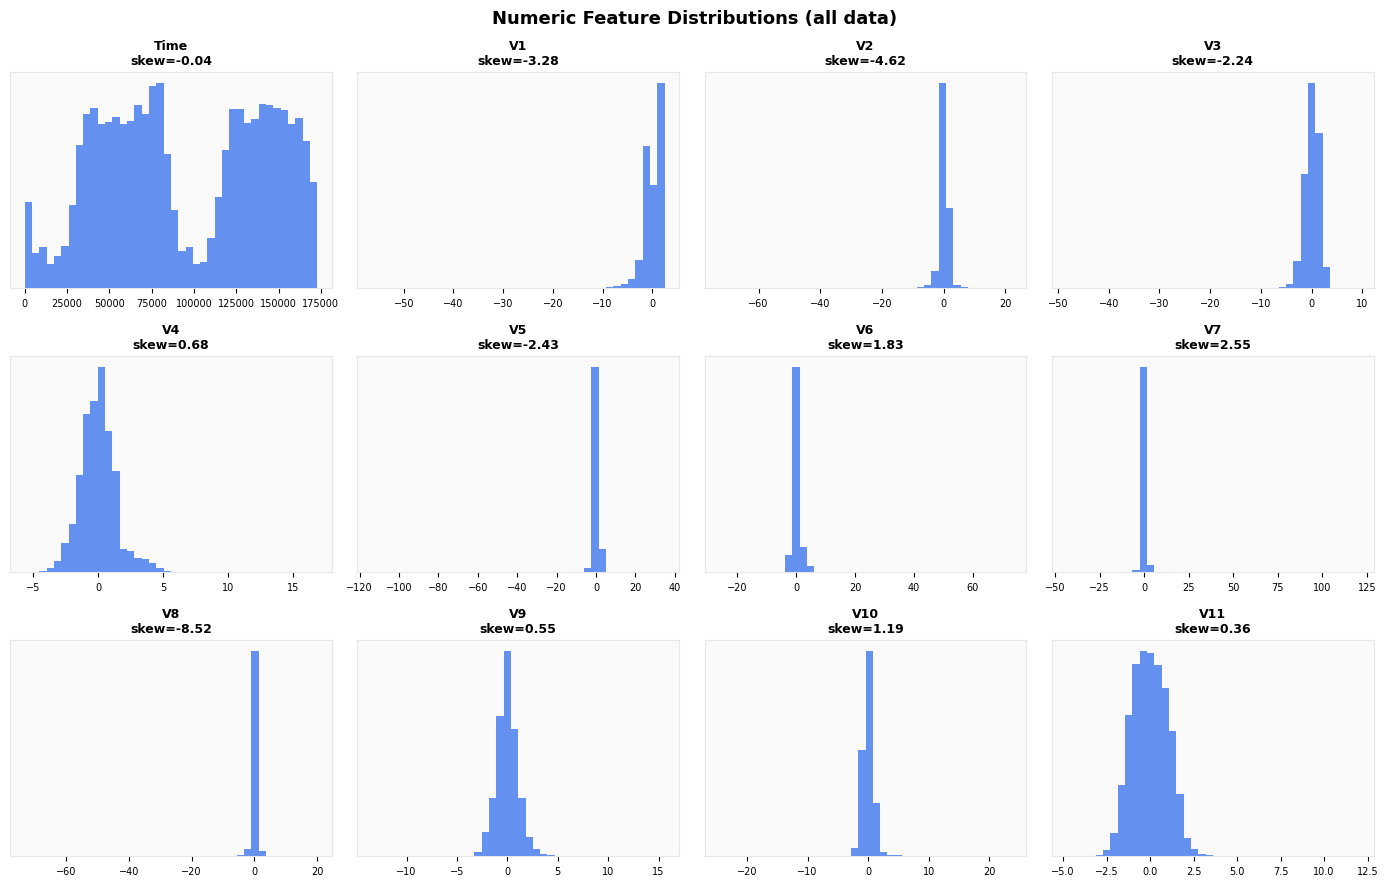

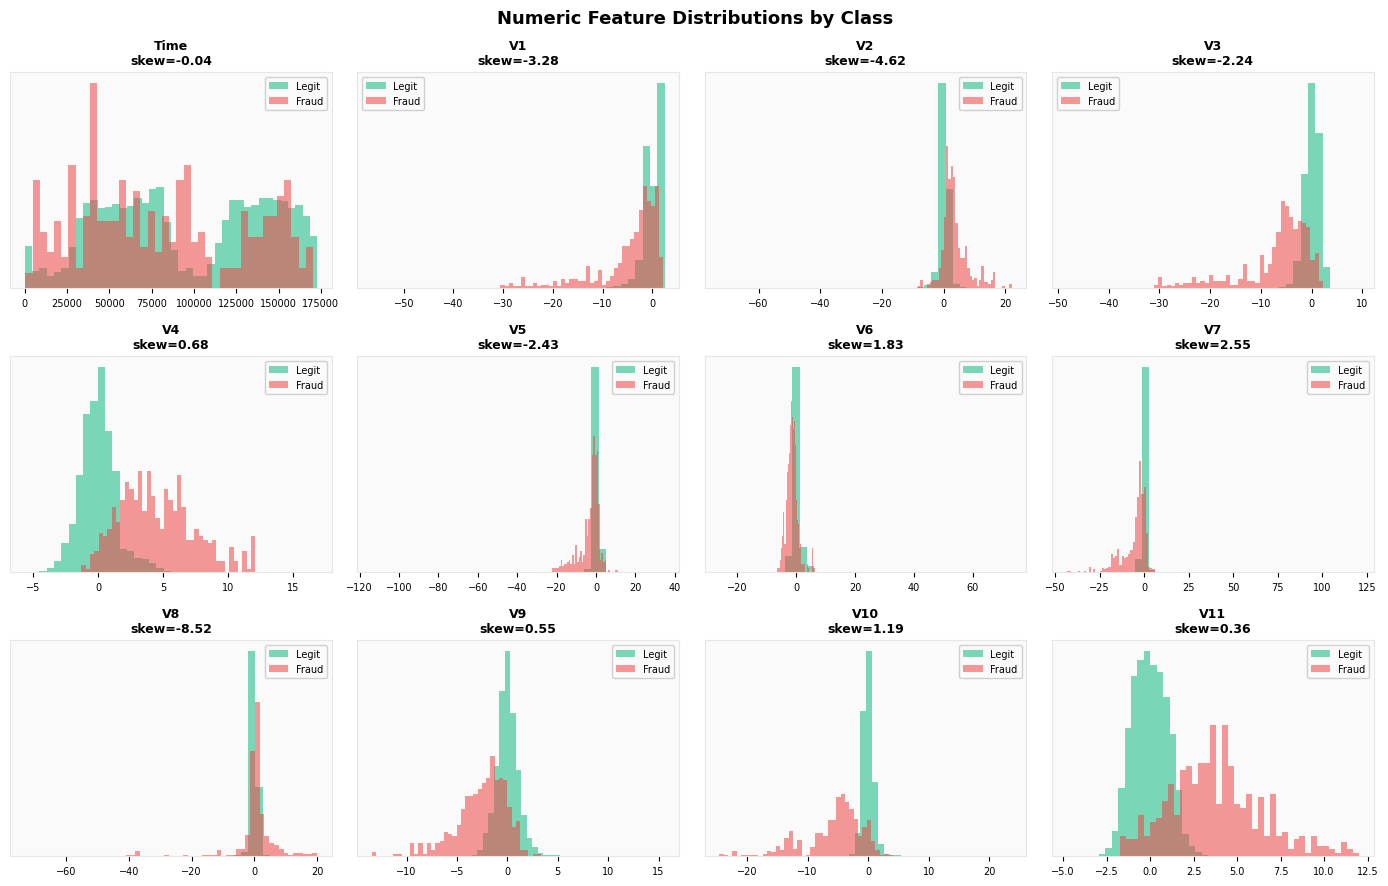

In [26]:
# Histograms — all numeric features, split by class
fig = viz.plot_feature_histograms(df, target="Class", max_cols=12, ncols=4, split_by_class= False)
fig = viz.plot_feature_histograms(df, target="Class", max_cols=12, ncols=4, split_by_class= True)
plt.show()


  Saved → ..\reports\figures\05_boxplots_by_class.png
  Saved → ..\reports\figures\05_boxplots.png


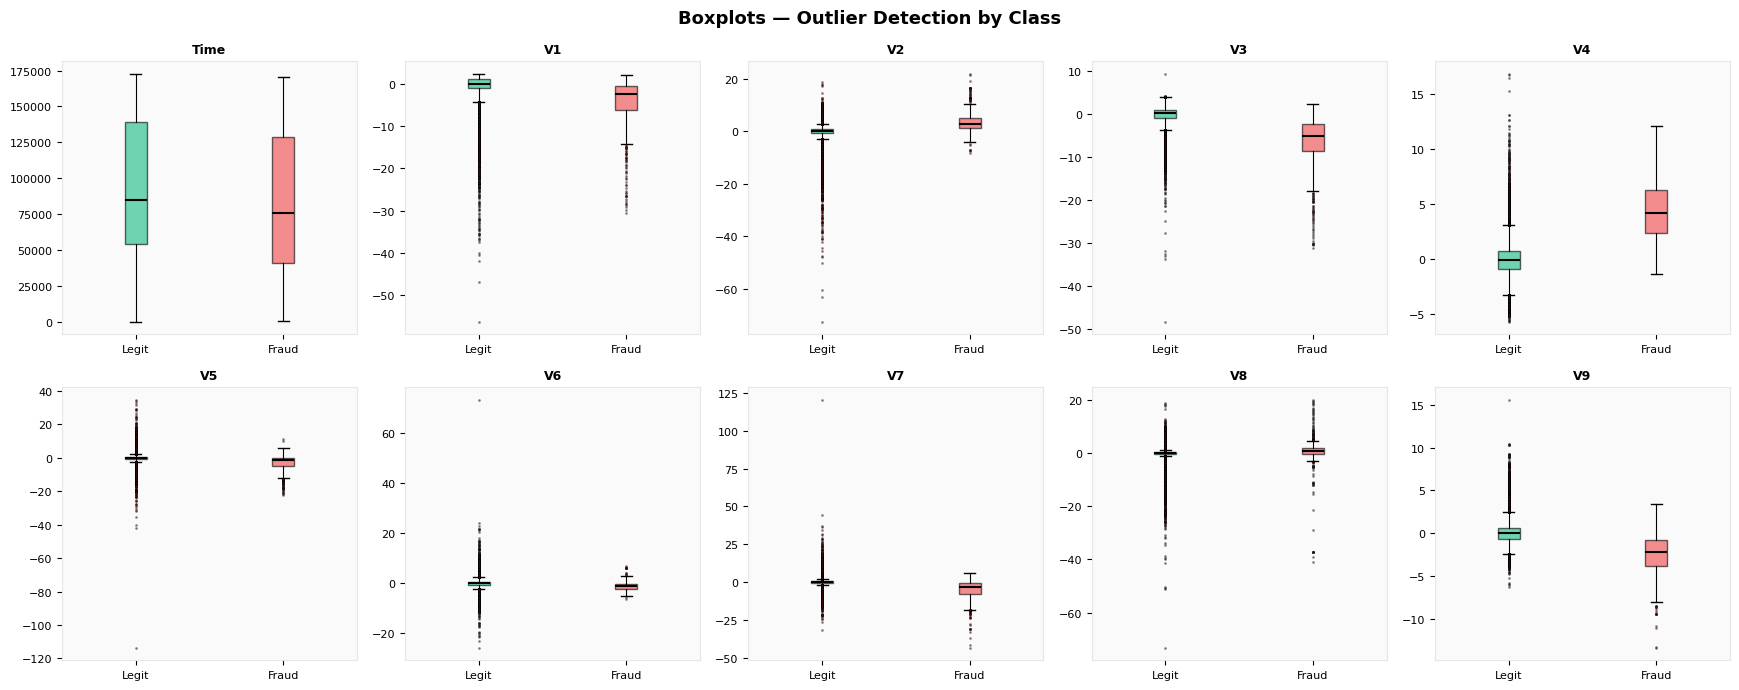

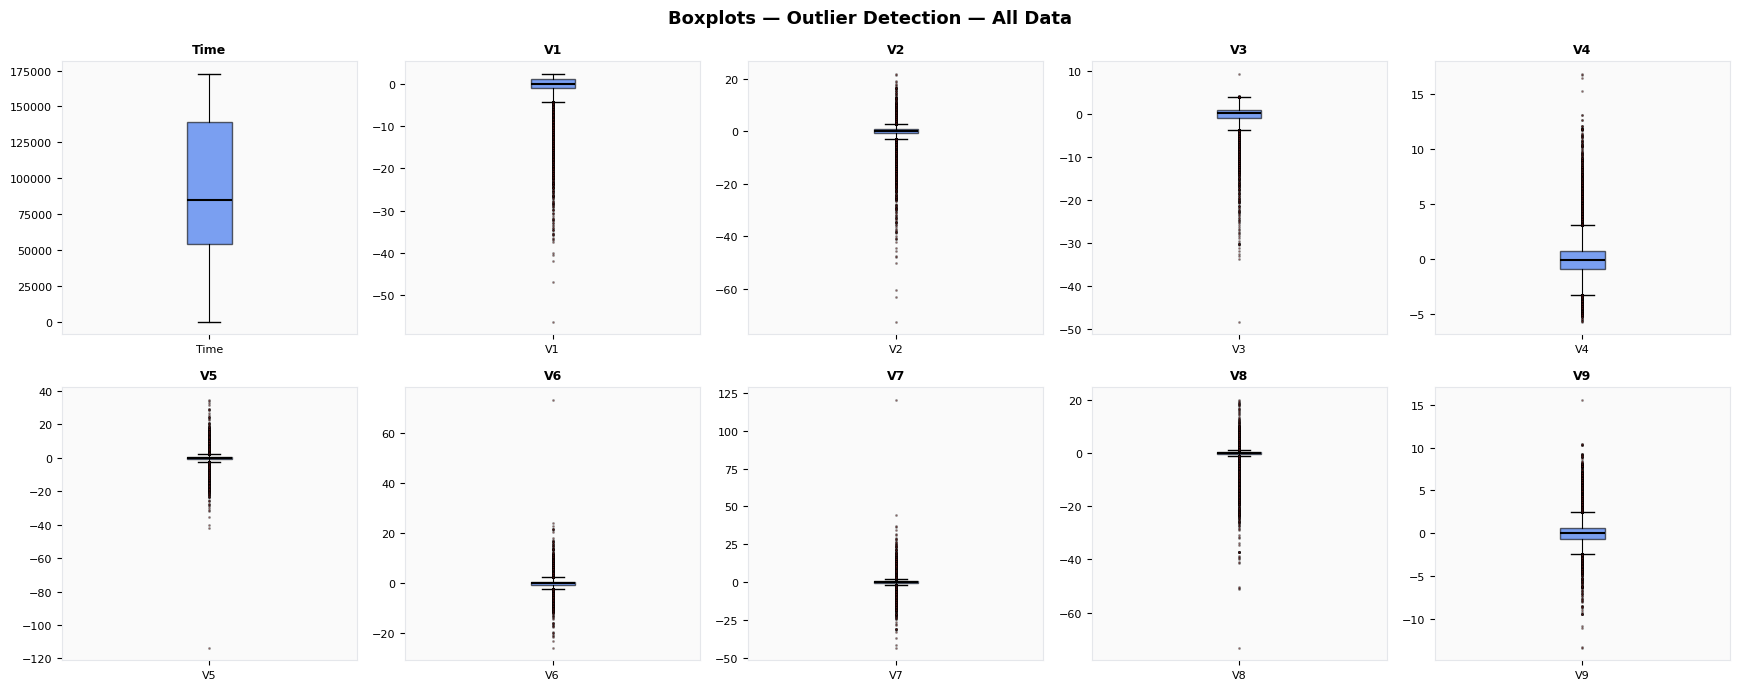

In [28]:
# Boxplots — detect outliers per feature per class
fig = viz.plot_boxplots(df, target="Class", top_n=10,split_by_class= True)
fig = viz.plot_boxplots(df, target="Class", top_n=10,split_by_class= False)
plt.show()


 ### 3.1 Amount — the only non-PCA financial feature

In [15]:
print("=== Amount statistics ===")
print(df["Amount"].describe())
print(f"\nSkewness : {df['Amount'].skew():.4f}")
print(f"Kurtosis : {df['Amount'].kurtosis():.4f}")


=== Amount statistics ===
count   284807.0000
mean        88.3496
std        250.1201
min          0.0000
25%          5.6000
50%         22.0000
75%         77.1650
max      25691.1600
Name: Amount, dtype: float64

Skewness : 16.9777
Kurtosis : 845.0926


  Saved → ..\reports\figures\08_amount_distribution.png


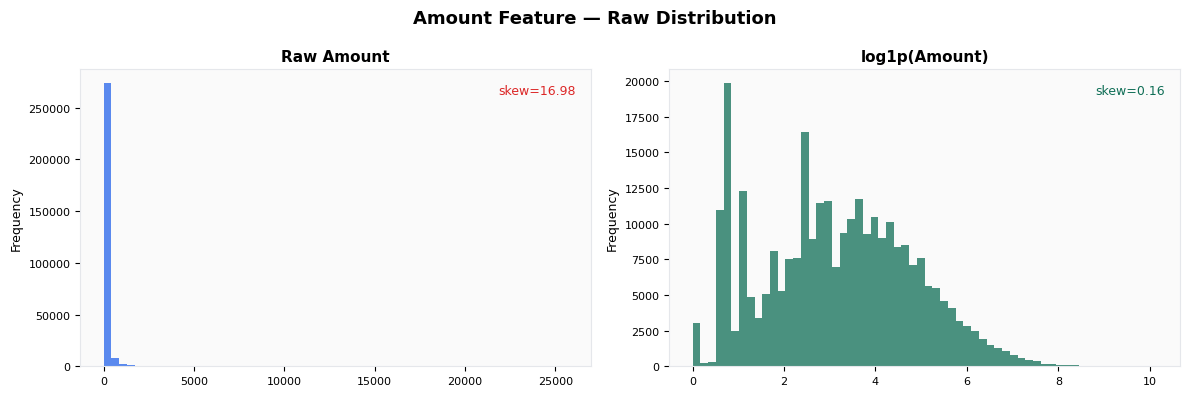

In [16]:
fig = viz.plot_amount_distribution(df)
plt.show()


 ### 3.2 Time — transaction timestamps

In [17]:
print("=== Time statistics ===")
print(df["Time"].describe())
print(f"\nSpan: {df['Time'].max() / 3600:.1f} hours ({df['Time'].max() / 86400:.1f} days)")


=== Time statistics ===
count   284807.0000
mean     94813.8596
std      47488.1460
min          0.0000
25%      54201.5000
50%      84692.0000
75%     139320.5000
max     172792.0000
Name: Time, dtype: float64

Span: 48.0 hours (2.0 days)


  Saved → ..\reports\figures\09_time_analysis_full.png
  Saved → ..\reports\figures\09_time_analysis.png


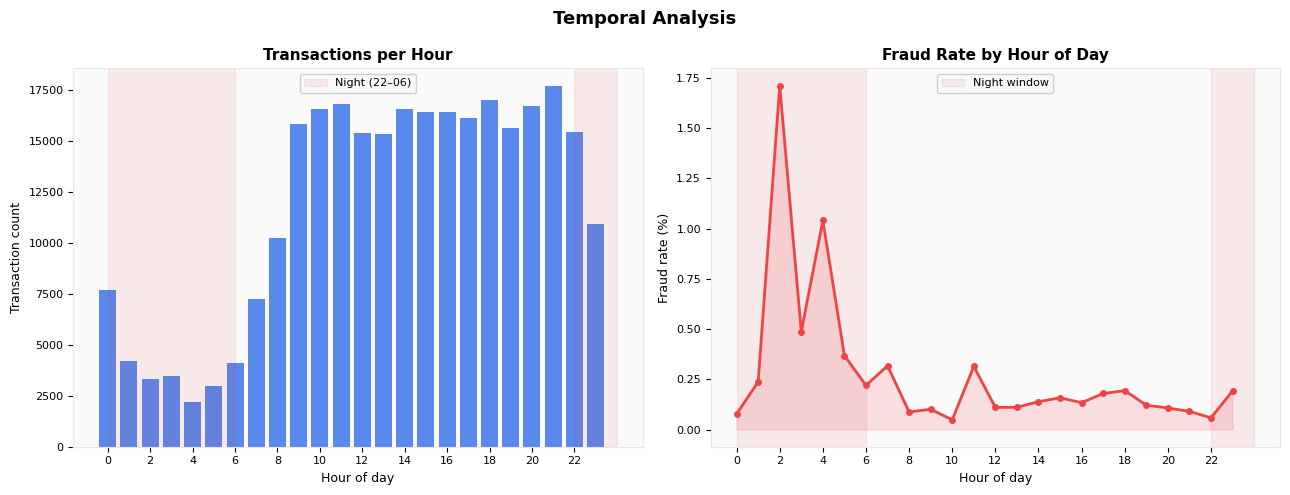

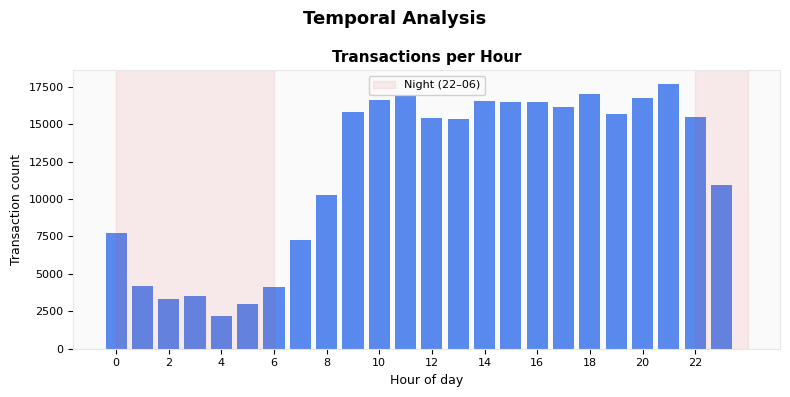

In [29]:
fig = viz.plot_time_analysis(df, show_fraud_rate= True)
fig = viz.plot_time_analysis(df, show_fraud_rate= False)
plt.show()


 ---

 ## 4. Correlations

  Saved → ..\reports\figures\06_correlation_heatmap.png


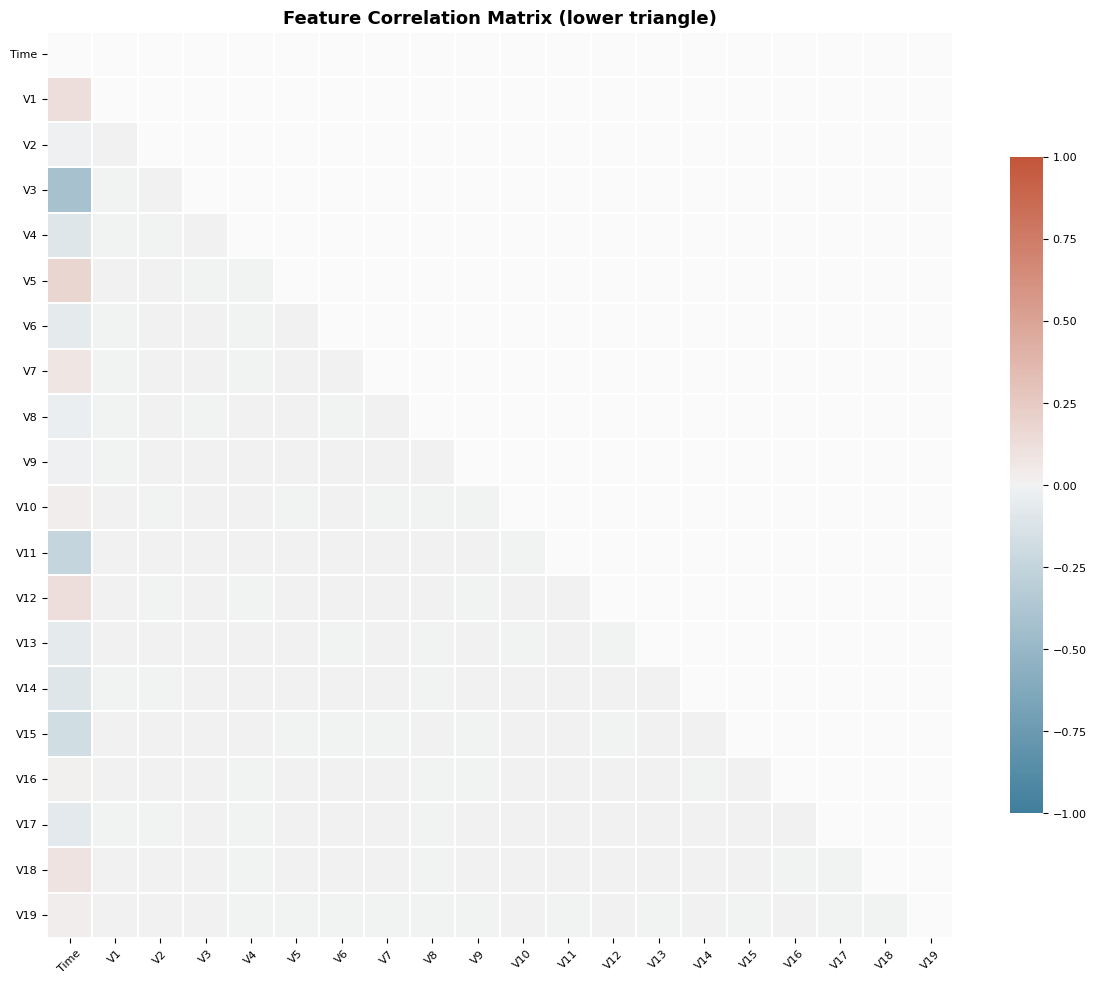

In [19]:
# Full correlation heatmap
fig = viz.plot_correlation_heatmap(df, max_cols=20)
plt.show()


  Saved → ..\reports\figures\07_feature_target_corr.png


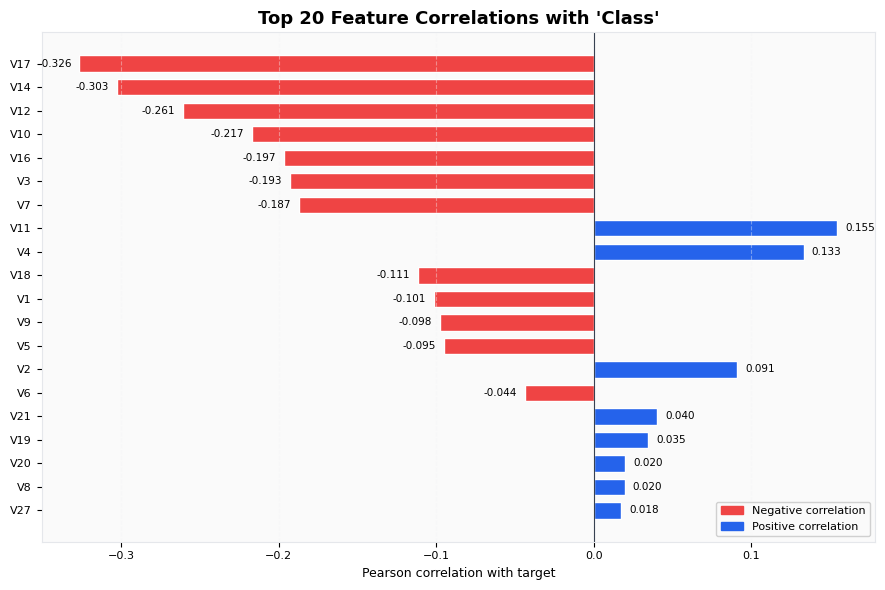

In [20]:
# Feature–target correlations
fig = viz.plot_feature_target_correlation(df, target="Class", top_n=20)
plt.show()


 ### Key observations from EDA



 | Finding | Impact |

 |---|---|

 | 0 missing values | No imputation needed |

 | 1,081 duplicates | Must be removed before training |

 | Fraud rate 0.173% | SMOTE required |

 | Amount: skew=17.5 | log1p transform needed |

 | V17, V14 most correlated with fraud | Strong PCA signals |

 | Fraud spikes overnight (22:00–06:00) | `is_night` feature useful |

 ---

 ## 5. Validation Report

In [21]:
from src.utils.logger import get_logger

logger = get_logger("test")

print(logger)
print(type(logger))

<Logger test (INFO)>
<class 'logging.Logger'>


In [22]:
validator  = DataValidator(config_path="../configs/data_config.yaml")
val_report = validator.validate(df)
validator.print_report(val_report)


<Logger src.data.data_validation (INFO)>
<class 'logging.Logger'>


2026-06-09 15:48:27 | INFO     | src.data.data_validation | Validation complete — PASS: 6 | WARN: 2 | FAIL: 0



─────────────────────────────────────────────────────────────────
  VALIDATION REPORT
─────────────────────────────────────────────────────────────────
  ✅ [PASS] not_empty                 284,807 rows — OK
  ✅ [PASS] target_exists             Target 'Class' found — 2 unique classes.
  ✅ [PASS] missing_values            Total missing cells: 0
  ✅ [PASS] duplicates                1,081 duplicate rows (0.38%)
  ⚠️  [WARN] constant_columns          1 near-zero-variance column(s) detected.
           → Class
  ✅ [PASS] high_cardinality          No high-cardinality categorical columns.
  ✅ [PASS] multicollinearity         No pairs exceed |ρ| = 0.95.
  ⚠️  [WARN] target_balance            Severe imbalance: minority class = 0.173%. SMOTE or cost-sensitive learning recommended.
           → 0: 284315
           → 1: 492
─────────────────────────────────────────────────────────────────
  PASS: 6  WARN: 2  FAIL: 0
  Overall: ✅ PASSED
─────────────────────────────────────────────────────────────